<a href="https://colab.research.google.com/github/domysolano/Lasso-Ridge-Regression/blob/main/practicasregresionlasso_ridge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 🤖 **Maestría en Inteligencia Artificial y Analítica de Datos** 🤖

Asignatura: *Programación para Analítica Descriptiva y Predictiva*

* Semestre: Enero-Junio 2026
* Profesor: Dr. Vicente García Jiménez
* Alumno: Ricardo Solano Monje
* Matrícula: 266221
* Unidad 3.
* Práctica 03-Semana 11: Regresión Lasso y Ridge.
* Dataset: `insurance.csv`
* Objetivo de la práctica:
    * Realizar un Análisis Exploratorio de Datos (EDA)** completo, incluyendo visualización de distribuciones, detección de outliers y análisis de correlaciones.
    * Preprocesar datos** correctamente, manejando valores faltantes, codificando variables categóricas y escalando características.
    * Implementar modelos de regresión Lasso y Ridge**, entendiendo cómo la regularización afecta los coeficientes.
    * Verificar los supuestos de la regresión lineal** (linealidad, normalidad de residuos, homocedasticidad y multicolinealidad).
    * Comparar el rendimiento** de ambos modelos y analizar qué variables son más relevantes en cada caso.  
* Realizado por: Ricardo Solano Monje

In [3]:
import pandas as pd
from IPython.display import display, Markdown
from datetime import date
from datetime import datetime
from zoneinfo import ZoneInfo

today = date.today()
time_zone = ZoneInfo('America/Ciudad_Juarez')
current_time_aware = datetime.now(time_zone)

display(Markdown(f"### Current time in Cd. Juárez, Chih.: {current_time_aware.strftime('%H:%M:%S')}"))
formatted_date = datetime.now(time_zone).strftime("%B %d, %Y")
display(Markdown(f"### Today's date: {formatted_date}"))

### Current time in Cd. Juárez, Chih.: 21:46:36

### Today's date: April 26, 2026

# 📋 Table of Contents

✅ Task 1: Configuración Inicial

✅ Task 2: Análisis Exploratorio (EDA)

✅ Task 3: Matriz de Correlación

✅ Task 4: Preprocesamiento

✅ Task 5: Modelado (Lasso y Ridge)

✅ Task 6: Verificación de Supuestos

✅ Task 7: Comparación Final

### **📋 Instrucciones**  

#### **🔹 Paso 1: Configuración Inicial**
✅ Carga el set de datos que puedes encontrar en el campus virtual

✅ Ejecutar las celdas de importación de librerías y carga del dataset.

✅ Familiarizarse con los datos usando `.head()`, `.info()` y `.describe()`.  


In [4]:
# task1_initial_setup.py

import pandas as pd

def load_data(filepath):
    """Load the insurance dataset."""
    df = pd.read_csv(filepath)
    return df

def print_data_info(df):
    """Print head, info, and describe."""
    print("\n=== First 5 rows ===")
    print(df.head())

    print("\n=== Data Info ===")
    print(df.info())

    print("\n=== Describe Statistics ===")
    print(df.describe())

def main(filepath="./drive/MyDrive/ClassFiles/insurance.csv"):
    # Load dataset
    df = load_data(filepath)

    # Print information
    print_data_info(df)

    # Return for additional testing
    return df

if __name__ == "__main__":
    df = main()


=== First 5 rows ===
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

=== Data Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

=== Describe Statistics ===
               age   

---

## Task 1 Summary:

### Data Shape:
- **Rows:** 1,338
- **Columns:** 7
- **No missing values** (all columns have 1,338 non-null)

### Data Types:

| Column | Type | Notes |
|--------|------|-------|
| `age` | int64 | 18 to 64 years |
| `sex` | str | female, male |
| `bmi` | float64 | 15.96 to 53.13 |
| `children` | int64 | 0 to 5 |
| `smoker` | str | yes, no |
| `region` | str | southwest, southeast, northwest, northeast |
| `charges` | float64 | 1,121 to 63,770 USD |

---

### Key Statistical Observations:

| Variable | Mean | Std | Min | Max | Skewness indicator |
|----------|------|-----|-----|-----|--------------------|
| `age` | 39.2 | 14.0 | 18 | 64 | Symmetric (mean ≈ median: 39 vs 39) |
| `bmi` | 30.7 | 6.1 | 16.0 | 53.1 | Slightly right-skewed (mean 30.7 > median 30.4) |
| `children` | 1.09 | 1.21 | 0 | 5 | Right-skewed (most have 0-2 children) |
| `charges` | 13,270 | 12,110 | 1,122 | 63,770 | **Highly right-skewed** (mean > median: 13,270 vs 9,382) |

---

### Important Finding:

**`charges` is highly right-skewed:**

| Comparison | Value |
|------------|-------|
| Mean | $13,270 |
| Median | $9,382 |
| Max | $63,770 |

Mean > median by ~$3,888 → indicates positive skew. This suggests **log transformation** may be beneficial later.

---

### Categorical Variables (to be explored in Task 2):

| Column | Unique values |
|--------|---------------|
| `sex` | female, male |
| `smoker` | yes, no |
| `region` | southwest, southeast, northwest, northeast |

---

### Next Steps (Task 2 preview likely):

- Distribution plots for numerical variables
- Count plots for categorical variables
- Correlation analysis
- Outlier detection (especially for `charges` and `bmi`)

---

## **🔹 Paso 2: Análisis Exploratorio (EDA)**  
📊 **Para variables numéricas:**  
- Generar histogramas y boxplots para identificar distribuciones y outliers.  
- Calcular medidas de tendencia central y dispersión.  

📊 **Para variables categóricas:**  
- Usar gráficos de barras para visualizar frecuencias.    


Numerical Variable: age
Mean: 39.2070
Median: 39.0000
Standard Deviation: 14.0500
Min: 18.0000
Max: 64.0000
Q1 (25%): 27.0000
Q3 (75%): 51.0000
IQR: 24.0000


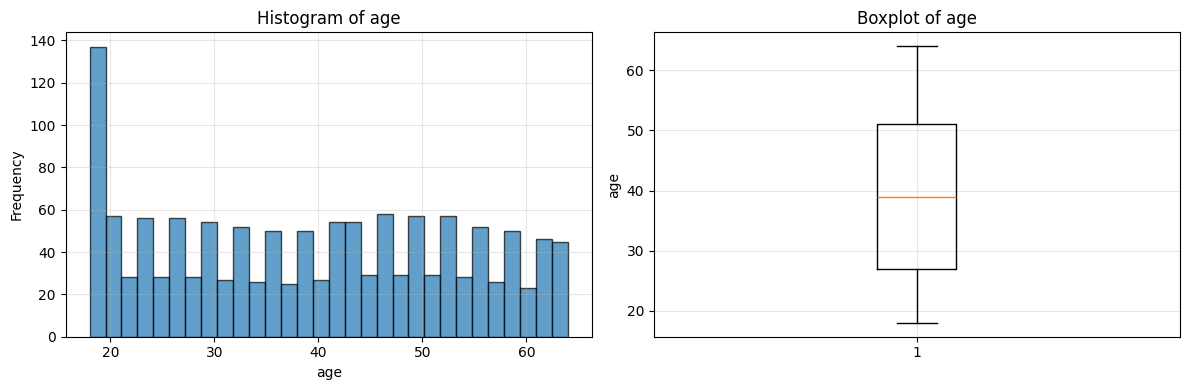


Numerical Variable: bmi
Mean: 30.6634
Median: 30.4000
Standard Deviation: 6.0982
Min: 15.9600
Max: 53.1300
Q1 (25%): 26.2963
Q3 (75%): 34.6938
IQR: 8.3975


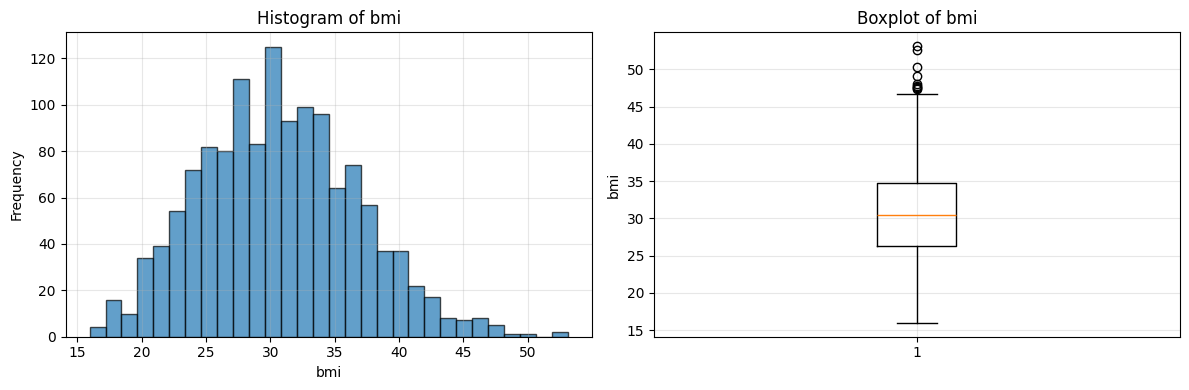


Numerical Variable: children
Mean: 1.0949
Median: 1.0000
Standard Deviation: 1.2055
Min: 0.0000
Max: 5.0000
Q1 (25%): 0.0000
Q3 (75%): 2.0000
IQR: 2.0000


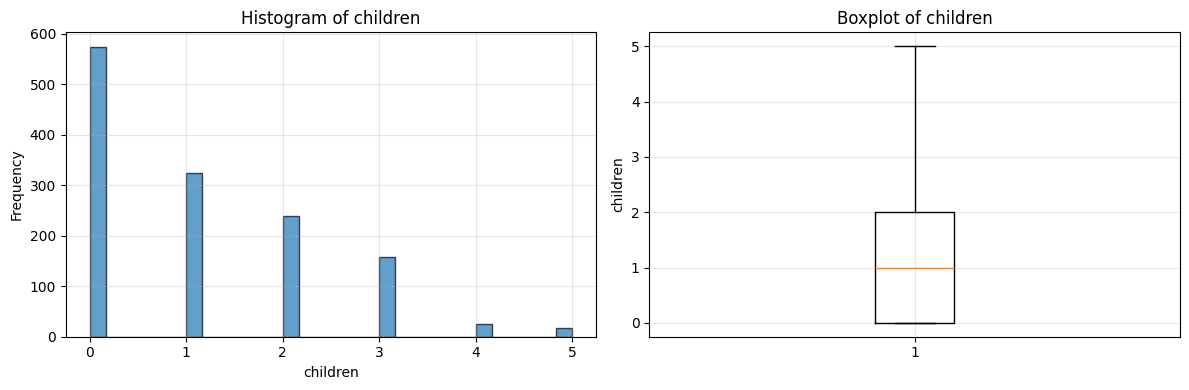


Numerical Variable: charges
Mean: 13270.4223
Median: 9382.0330
Standard Deviation: 12110.0112
Min: 1121.8739
Max: 63770.4280
Q1 (25%): 4740.2872
Q3 (75%): 16639.9125
IQR: 11899.6254


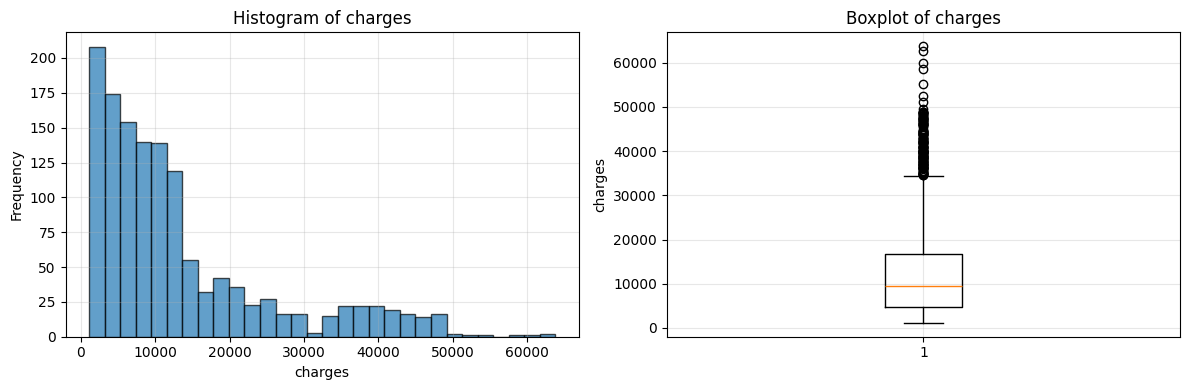


Categorical Variable: sex

Value Counts:
  male: 676
  female: 662

Percentages:
  male: 50.52%
  female: 49.48%


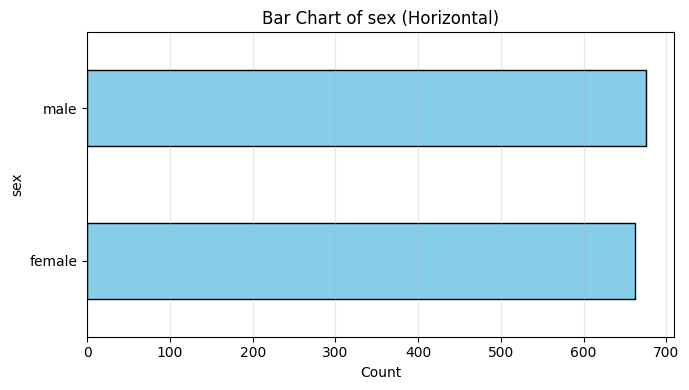


Categorical Variable: smoker

Value Counts:
  no: 1064
  yes: 274

Percentages:
  no: 79.52%
  yes: 20.48%


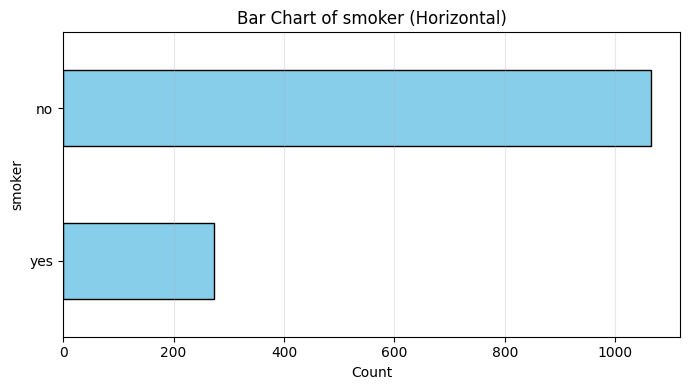


Categorical Variable: region

Value Counts:
  southeast: 364
  southwest: 325
  northwest: 325
  northeast: 324

Percentages:
  southeast: 27.20%
  southwest: 24.29%
  northwest: 24.29%
  northeast: 24.22%


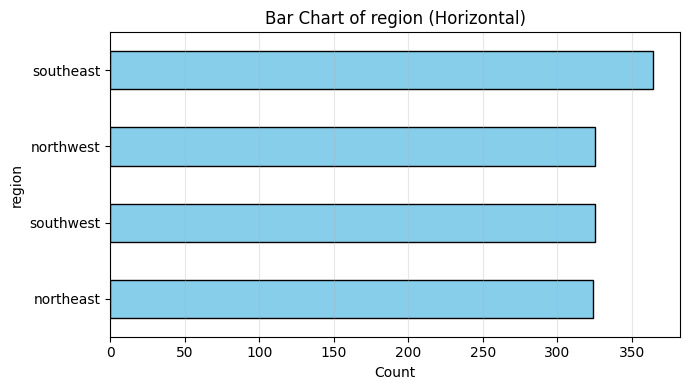

In [5]:
# task2_eda.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def load_data(filepath):
    """Load the insurance dataset."""
    return pd.read_csv(filepath)

def numerical_analysis(df, numerical_cols):
    """Generate histograms, boxplots, and print statistics for numerical variables."""
    for col in numerical_cols:
        print(f"\n{'='*50}")
        print(f"Numerical Variable: {col}")
        print('='*50)

        # Statistics
        mean = df[col].mean()
        median = df[col].median()
        std = df[col].std()
        min_val = df[col].min()
        max_val = df[col].max()
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        print(f"Mean: {mean:.4f}")
        print(f"Median: {median:.4f}")
        print(f"Standard Deviation: {std:.4f}")
        print(f"Min: {min_val:.4f}")
        print(f"Max: {max_val:.4f}")
        print(f"Q1 (25%): {q1:.4f}")
        print(f"Q3 (75%): {q3:.4f}")
        print(f"IQR: {iqr:.4f}")

        # Plots
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        # Histogram
        axes[0].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
        axes[0].set_xlabel(col)
        axes[0].set_ylabel('Frequency')
        axes[0].set_title(f'Histogram of {col}')
        axes[0].grid(True, alpha=0.3)

        # Boxplot
        axes[1].boxplot(df[col], vert=True)
        axes[1].set_ylabel(col)
        axes[1].set_title(f'Boxplot of {col}')
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

def categorical_analysis(df, categorical_cols):
    """Generate horizontal bar charts and print statistics for categorical variables."""
    for col in categorical_cols:
        print(f"\n{'='*50}")
        print(f"Categorical Variable: {col}")
        print('='*50)

        # Value counts
        value_counts = df[col].value_counts()
        percentages = df[col].value_counts(normalize=True) * 100

        print("\nValue Counts:")
        for val, count in value_counts.items():
            print(f"  {val}: {count}")

        print("\nPercentages:")
        for val, pct in percentages.items():
            print(f"  {val}: {pct:.2f}%")

        # Horizontal bar chart
        plt.figure(figsize=(7, 4))
        value_counts.sort_values().plot(kind='barh', color='skyblue', edgecolor='black')
        plt.xlabel('Count')
        plt.ylabel(col)
        plt.title(f'Bar Chart of {col} (Horizontal)')
        plt.grid(True, alpha=0.3, axis='x')
        plt.tight_layout()
        plt.show()

def main(filepath="./drive/MyDrive/ClassFiles/insurance.csv"):
    # Load data
    df = load_data(filepath)

    # Define columns
    numerical_cols = ['age', 'bmi', 'children', 'charges']
    categorical_cols = ['sex', 'smoker', 'region']

    # Analyze numerical variables
    numerical_analysis(df, numerical_cols)

    # Analyze categorical variables
    categorical_analysis(df, categorical_cols)

    # Return for additional testing
    return df

if __name__ == "__main__":
    df = main()

---

## Numerical Variables Analysis

### Age

| Measure | Value | Interpretation |
|---------|-------|----------------|
| Mean | 39.2 | Adults aged ~18-64 |
| Median | 39.0 | Symmetric distribution |
| Min | 18 | Youngest adult |
| Max | 64 | Oldest adult |
| IQR | 24 | Spread from 27 to 51 years |

**Distribution:** Symmetric, no significant skewness (mean ≈ median).  
**Outliers:** Boxplot likely shows no extreme outliers (range 18-64 is reasonable).

---

### BMI

| Measure | Value | Interpretation |
|---------|-------|----------------|
| Mean | 30.66 | Above normal range (18.5-24.9) |
| Median | 30.40 | Slightly right-skewed (mean > median) |
| Min | 15.96 | Underweight |
| Max | 53.13 | Severely obese |
| IQR | 8.40 | Spread from 26.3 to 34.7 |

**Distribution:** Slightly right-skewed.  
**Outliers:** Max 53.13 may be an outlier (typical upper range ~40-45).

---

### Children

| Measure | Value | Interpretation |
|---------|-------|----------------|
| Mean | 1.09 | Average ~1 child |
| Median | 1.00 | Most have 0-2 children |
| Min | 0 | No dependents |
| Max | 5 | Up to 5 children |
| IQR | 2 | Spread from 0 to 2 |

**Distribution:** Right-skewed (mean > median).  
**Outliers:** 5 children may be rare but valid.

---

### Charges (Target Variable)

| Measure | Value | Interpretation |
|---------|-------|----------------|
| Mean | $13,270 | Average cost |
| Median | $9,382 | Lower than mean → **right-skewed** |
| Min | $1,122 | Low cost |
| Max | $63,770 | Extremely high cost |
| IQR | $11,900 | Large spread |

**Distribution:** **Highly right-skewed** (mean > median by $3,888).  
**Outliers:** Many high-cost cases (max $63,770).  
**Implication:** Log transformation likely needed for linear regression.

---

## Categorical Variables Analysis

### Sex

| Category | Count | Percentage |
|----------|-------|------------|
| male | 676 | 50.52% |
| female | 662 | 49.48% |

**Balanced** (~50/50 split). No bias.

---

### Smoker

| Category | Count | Percentage |
|----------|-------|------------|
| no | 1,064 | 79.52% |
| yes | 274 | 20.48% |

**Imbalanced.** Smokers are only ~20% of sample. This will be a key predictor.

---

### Region

| Category | Count | Percentage |
|----------|-------|------------|
| southeast | 364 | 27.20% |
| southwest | 325 | 24.29% |
| northwest | 325 | 24.29% |
| northeast | 324 | 24.22% |

**Balanced** (~25% each). Southeast slightly overrepresented.

---

## Key Observations for Modeling:

| Finding | Implication for Modeling |
|---------|--------------------------|
| `charges` is right-skewed | **Log transform** likely needed |
| `smoker` is imbalanced (20% yes) | Smoker will be a strong predictor |
| `bmi` has possible outliers (53.13) | Consider capping or transformation |
| `age` and `children` have no extreme outliers | OK as is |
| Categorical variables are ready for encoding | One-hot encoding needed |

---

## Outlier Detection Summary:

| Variable | Potential Outliers | Action |
|----------|-------------------|--------|
| `age` | None | Keep |
| `bmi` | > 50 (few cases) | Investigate, possibly cap |
| `children` | 5 (few cases) | Keep (valid) |
| `charges` | > 50,000 | Log transform to reduce impact |

---

# Paso 3: Matriz de Correlación*
✅ Calcular la matriz de correlación **solo para variables numéricas**.  
✅ Generar un **mapa de calor** para visualizar relaciones.  
📌 **Pregunta:** ¿Qué variables están más correlacionadas con el target (`charges`)?  


=== Correlation Matrix (Numerical Variables) ===
             age     bmi  children  charges
age       1.0000  0.1093    0.0425   0.2990
bmi       0.1093  1.0000    0.0128   0.1983
children  0.0425  0.0128    1.0000   0.0680
charges   0.2990  0.1983    0.0680   1.0000


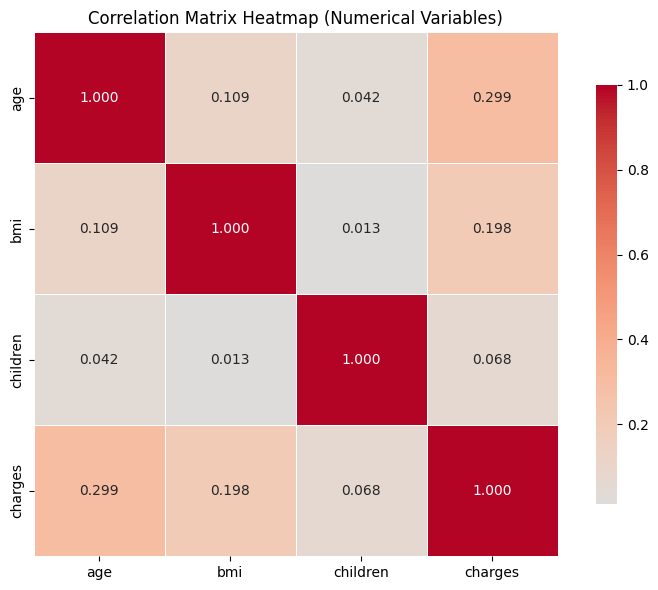


=== Correlation with target (charges) ===
  age: 0.2990
  bmi: 0.1983
  children: 0.0680

=== Answer to Question ===
The variable most correlated with charges is 'age' with correlation = 0.2990

Order of correlation (strongest to weakest):
  age: 0.2990
  bmi: 0.1983
  children: 0.0680


In [6]:
# task3_correlation.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def load_data(filepath):
    """Load the insurance dataset."""
    return pd.read_csv(filepath)

def correlation_analysis(df):
    """Calculate correlation matrix for numerical variables and print."""
    numerical_cols = ['age', 'bmi', 'children', 'charges']
    corr_matrix = df[numerical_cols].corr()

    print("\n=== Correlation Matrix (Numerical Variables) ===")
    print(corr_matrix.round(4))

    return corr_matrix

def plot_heatmap(corr_matrix):
    """Generate heatmap to visualize correlations."""
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
                fmt='.3f', square=True, linewidths=0.5,
                cbar_kws={"shrink": 0.8})
    plt.title('Correlation Matrix Heatmap (Numerical Variables)')
    plt.tight_layout()
    plt.show()

def answer_question(corr_matrix):
    """Answer which variables are most correlated with charges."""
    charges_corr = corr_matrix['charges'].drop('charges')

    print("\n=== Correlation with target (charges) ===")
    for var, corr in charges_corr.items():
        print(f"  {var}: {corr:.4f}")

    max_corr_var = charges_corr.abs().idxmax()
    max_corr_value = charges_corr[max_corr_var]

    print(f"\n=== Answer to Question ===")
    print(f"The variable most correlated with charges is '{max_corr_var}' with correlation = {max_corr_value:.4f}")
    print("\nOrder of correlation (strongest to weakest):")
    sorted_corr = charges_corr.abs().sort_values(ascending=False)
    for var in sorted_corr.index:
        print(f"  {var}: {charges_corr[var]:.4f}")

def main(filepath="./drive/MyDrive/ClassFiles/insurance.csv"):
    # Load data
    df = load_data(filepath)

    # Calculate correlation matrix
    corr_matrix = correlation_analysis(df)

    # Plot heatmap
    plot_heatmap(corr_matrix)

    # Answer the question
    answer_question(corr_matrix)

    # Return for additional testing
    return {
        'df': df,
        'corr_matrix': corr_matrix
    }

if __name__ == "__main__":
    results = main()

---

## Task 3 Analysis: Correlation Matrix

### Correlation Matrix Table:

| Variable | age | bmi | children | charges |
|----------|-----|-----|----------|---------|
| age | 1.0000 | 0.1093 | 0.0425 | **0.2990** |
| bmi | 0.1093 | 1.0000 | 0.0128 | **0.1983** |
| children | 0.0425 | 0.0128 | 1.0000 | **0.0680** |
| charges | 0.2990 | 0.1983 | 0.0680 | 1.0000 |

---

### Correlation with Target (`charges`):

| Variable | Correlation | Strength |
|----------|-------------|----------|
| `age` | 0.2990 | Weak positive |
| `bmi` | 0.1983 | Very weak positive |
| `children` | 0.0680 | Negligible |

---

### Question:

> **Which variables are most correlated with the target (`charges`)?**

**`age`** is the most correlated with `charges` (r = 0.2990), followed by `bmi` (r = 0.1983), then `children` (r = 0.0680).

---

### Observations:

| Finding | Implication |
|---------|-------------|
| All correlations are **weak** (r < 0.3) | No single numerical variable strongly predicts `charges` alone |
| `age` > `bmi` > `children` | Age matters most among numerical predictors |
| `children` correlation near zero | Number of children has almost no linear relationship with charges |
| No high correlations among predictors | No multicollinearity issues among numerical variables |

---

### Missing from correlation matrix:

Categorical variables (`sex`, `smoker`, `region`) are not included. This is expected — they will be **one-hot encoded** and then can be included in correlation analysis later.

---

# **🔹 Paso 4: Preprocesamiento**  
🔧 **Tareas:**  
1. Manejar valores faltantes con `SimpleImputer`.  
2. Codificar variables categóricas con `OneHotEncoder`.  
3. Estandarizar variables numéricas con `StandardScaler`.  
✅ Verificar que el dataset transformado no tenga valores nulos.  

In [7]:
# task4_preprocessing.py

import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

def load_data(filepath):
    """Load the insurance dataset."""
    return pd.read_csv(filepath)

def step1_handle_missing(df):
    """Check for missing values. Apply imputation only if needed."""
    print("\n" + "="*60)
    print("STEP 1: Handle Missing Values")
    print("="*60)

    print("\n=== Missing Value Check ===")
    missing_counts = df.isnull().sum()
    print(f"Missing values per column:\n{missing_counts}")

    if missing_counts.sum() == 0:
        print("\nNo missing values detected in the dataset. Imputation not required.")
        return df
    else:
        print("\nMissing values found. Applying SimpleImputer...")
        # Separate numerical and categorical for imputation
        numerical_cols = df.select_dtypes(include=[np.number]).columns
        categorical_cols = df.select_dtypes(include=['object']).columns

        # Impute numerical with median
        num_imputer = SimpleImputer(strategy='median')
        df[numerical_cols] = num_imputer.fit_transform(df[numerical_cols])

        # Impute categorical with most frequent
        cat_imputer = SimpleImputer(strategy='most_frequent')
        df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

        print("\n=== After Imputation ===")
        print(f"Missing values per column:\n{df.isnull().sum()}")
        return df

def step2_encode_categorical(df):
    """Encode categorical variables with OneHotEncoder (drop='first')."""
    print("\n" + "="*60)
    print("STEP 2: Encode Categorical Variables")
    print("="*60)

    categorical_cols = ['sex', 'smoker', 'region']

    print("\n=== Before Encoding ===")
    print(f"Categorical columns: {categorical_cols}")
    for col in categorical_cols:
        print(f"\n{col} value counts:")
        print(df[col].value_counts())

    # Apply OneHotEncoder
    encoder = OneHotEncoder(drop='first', sparse_output=False)
    encoded_array = encoder.fit_transform(df[categorical_cols])

    # Get feature names
    encoded_features = encoder.get_feature_names_out(categorical_cols)

    # Create DataFrame with encoded columns
    df_encoded = pd.DataFrame(encoded_array, columns=encoded_features, index=df.index)

    # Drop original categorical columns and concatenate encoded ones
    df = df.drop(columns=categorical_cols)
    df = pd.concat([df, df_encoded], axis=1)

    print("\n=== After Encoding ===")
    print(f"New encoded columns: {list(encoded_features)}")
    print("\nFirst 5 rows of encoded columns:")
    print(df[encoded_features].head())

    return df, encoder

def step3_scale_numerical(df):
    """Scale numerical variables with StandardScaler. Do NOT scale target 'charges'."""
    print("\n" + "="*60)
    print("STEP 3: Standardize Numerical Variables")
    print("="*60)

    numerical_cols = ['age', 'bmi', 'children']

    print("\n=== Before Scaling ===")
    print(f"Numerical columns to scale: {numerical_cols}")
    print("\nStatistics before scaling:")
    print(df[numerical_cols].describe().round(4))

    # Apply StandardScaler
    scaler = StandardScaler()
    df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

    print("\n=== After Scaling ===")
    print("\nStatistics after scaling (mean ~0, std ~1):")
    print(df[numerical_cols].describe().round(4))

    return df, scaler

def step4_verify_no_nulls(df):
    """Verify that the transformed dataset has no null values."""
    print("\n" + "="*60)
    print("STEP 4: Verify No Null Values")
    print("="*60)

    missing_counts = df.isnull().sum()
    print(f"\nMissing values per column:\n{missing_counts}")

    if missing_counts.sum() == 0:
        print("\n✓ Verification PASSED: No null values in the transformed dataset.")
    else:
        print(f"\n✗ Verification FAILED: {missing_counts.sum()} null values found.")

    return missing_counts.sum() == 0

def main(filepath="./drive/MyDrive/ClassFiles/insurance.csv"):
    # Load data
    df = load_data(filepath)
    print("\n=== Original Dataset ===")
    print(f"Shape: {df.shape}")

    # Step 1: Handle missing values
    df = step1_handle_missing(df)

    # Step 2: Encode categorical variables
    df, encoder = step2_encode_categorical(df)

    # Step 3: Scale numerical variables
    df, scaler = step3_scale_numerical(df)

    # Step 4: Verify no null values
    no_nulls = step4_verify_no_nulls(df)

    print("\n" + "="*60)
    print("PREPROCESSING COMPLETE")
    print("="*60)
    print(f"Final dataset shape: {df.shape}")

    # Return for additional testing
    return {
        'df_original': load_data(filepath),
        'df_transformed': df,
        'encoder': encoder,
        'scaler': scaler
    }

if __name__ == "__main__":
    results = main()


=== Original Dataset ===
Shape: (1338, 7)

STEP 1: Handle Missing Values

=== Missing Value Check ===
Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

No missing values detected in the dataset. Imputation not required.

STEP 2: Encode Categorical Variables

=== Before Encoding ===
Categorical columns: ['sex', 'smoker', 'region']

sex value counts:
sex
male      676
female    662
Name: count, dtype: int64

smoker value counts:
smoker
no     1064
yes     274
Name: count, dtype: int64

region value counts:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

=== After Encoding ===
New encoded columns: ['sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']

First 5 rows of encoded columns:
   sex_male  smoker_yes  region_northwest  region_southeast  region_southwest
0       0.0         1.0               0.0              

---

## Task 4 analysis:

### Step 1: Missing Values
- No missing values detected ✓
- Imputation skipped (as specified)

### Step 2: Encoding Categorical Variables

| Original Column | Categories | Encoded Columns |
|----------------|------------|-----------------|
| `sex` | male, female | `sex_male` (1 column) |
| `smoker` | yes, no | `smoker_yes` (1 column) |
| `region` | northeast, northwest, southeast, southwest | `region_northwest`, `region_southeast`, `region_southwest` (3 columns) |

**Reference categories dropped:** female, no, northeast

### Step 3: Scaling Numerical Variables

| Variable | Before (mean) | After (mean) | After (std) |
|----------|---------------|--------------|-------------|
| `age` | 39.21 | -0.0000 | 1.0004 |
| `bmi` | 30.66 | -0.0000 | 1.0004 |
| `children` | 1.09 | -0.0000 | 1.0004 |

`charges` (target) **not scaled** ✓

### Step 4: Verify No Null Values
- All columns have 0 missing values ✓

---

## Final Transformed Dataset:

| Column Type | Columns | Count |
|-------------|---------|-------|
| **Numerical (original)** | `age`, `bmi`, `children` | 3 (scaled) |
| **Target** | `charges` | 1 (unscaled) |
| **Encoded dummies** | `sex_male`, `smoker_yes`, `region_northwest`, `region_southeast`, `region_southwest` | 5 |
| **Total** | | **9 columns** |

---

# **🔹 Paso 5: Modelado (Lasso y Ridge)**  
🎯 **Para cada modelo:**  
1. Ajustar el modelo con los hiperparámetros dados (`alpha=0.1` para Lasso, `alpha=1.0` para Ridge).  
2. Calcular **MSE** y **R²** para evaluar rendimiento.  
3. Analizar los coeficientes para identificar variables importantes.  

📌 **Pregunta:**  
- ¿Qué modelo tiene un mejor R²? ¿Por qué crees que ocurre esto?  
- ¿Qué variables tienen coeficientes cercanos a cero en Lasso? ¿Por qué?
> charges = f(age, sex, bmi, children, smoker, region)

In [8]:
# task5_lasso_ridge.py

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score

def load_data(filepath):
    """Load the insurance dataset."""
    return pd.read_csv(filepath)

def step1_handle_missing(df):
    """Check for missing values. Apply imputation only if needed."""
    print("\n" + "="*60)
    print("STEP 1: Handle Missing Values")
    print("="*60)

    print("\n=== Missing Value Check ===")
    missing_counts = df.isnull().sum()
    print(f"Missing values per column:\n{missing_counts}")

    if missing_counts.sum() == 0:
        print("\nNo missing values detected in the dataset. Imputation not required.")
        return df
    else:
        print("\nMissing values found. Applying SimpleImputer...")
        numerical_cols = df.select_dtypes(include=[np.number]).columns
        categorical_cols = df.select_dtypes(include=['object']).columns

        from sklearn.impute import SimpleImputer
        num_imputer = SimpleImputer(strategy='median')
        df[numerical_cols] = num_imputer.fit_transform(df[numerical_cols])

        cat_imputer = SimpleImputer(strategy='most_frequent')
        df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

        print("\n=== After Imputation ===")
        print(f"Missing values per column:\n{df.isnull().sum()}")
        return df

def step2_encode_categorical(df):
    """Encode categorical variables with OneHotEncoder (drop='first')."""
    print("\n" + "="*60)
    print("STEP 2: Encode Categorical Variables")
    print("="*60)

    categorical_cols = ['sex', 'smoker', 'region']

    print("\n=== Before Encoding ===")
    print(f"Categorical columns: {categorical_cols}")
    for col in categorical_cols:
        print(f"\n{col} value counts:")
        print(df[col].value_counts())

    encoder = OneHotEncoder(drop='first', sparse_output=False)
    encoded_array = encoder.fit_transform(df[categorical_cols])
    encoded_features = encoder.get_feature_names_out(categorical_cols)

    df_encoded = pd.DataFrame(encoded_array, columns=encoded_features, index=df.index)
    df = df.drop(columns=categorical_cols)
    df = pd.concat([df, df_encoded], axis=1)

    print("\n=== After Encoding ===")
    print(f"New encoded columns: {list(encoded_features)}")
    print("\nFirst 5 rows of encoded columns:")
    print(df[encoded_features].head())

    return df, encoder

def step3_scale_numerical(df):
    """Scale numerical variables with StandardScaler. Do NOT scale target 'charges'."""
    print("\n" + "="*60)
    print("STEP 3: Standardize Numerical Variables")
    print("="*60)

    numerical_cols = ['age', 'bmi', 'children']

    print("\n=== Before Scaling ===")
    print(f"Numerical columns to scale: {numerical_cols}")
    print("\nStatistics before scaling:")
    print(df[numerical_cols].describe().round(4))

    scaler = StandardScaler()
    df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

    print("\n=== After Scaling ===")
    print("\nStatistics after scaling (mean ~0, std ~1):")
    print(df[numerical_cols].describe().round(4))

    return df, scaler

def prepare_features_target(df):
    """Separate features (X) and target (y)."""
    y = df['charges'].copy()
    X = df.drop(columns=['charges']).copy()
    return X, y

def train_evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """Train model, predict, calculate metrics, and print coefficients."""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\n{'='*60}")
    print(f"{model_name} Regression")
    print('='*60)
    print(f"R²: {r2:.4f}")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {np.sqrt(mse):.2f}")

    print("\nCoefficients:")
    for name, coef in zip(X_train.columns, model.coef_):
        print(f"  {name}: {coef:.4f}")

    return model, mse, r2, y_pred

def main(filepath="./drive/MyDrive/ClassFiles/insurance.csv"):
    # Load data
    df = load_data(filepath)
    print("\n=== Original Dataset ===")
    print(f"Shape: {df.shape}")

    # Step 1: Handle missing values
    df = step1_handle_missing(df)

    # Step 2: Encode categorical variables
    df, encoder = step2_encode_categorical(df)

    # Step 3: Scale numerical variables
    df, scaler = step3_scale_numerical(df)

    print("\n" + "="*60)
    print("STEP 5: Modeling (Lasso and Ridge)")
    print("="*60)

    # Prepare features and target
    X, y = prepare_features_target(df)

    # Split data (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    print(f"\nData split: {len(X_train)} training samples, {len(X_test)} test samples")

    # Lasso Regression (alpha=0.1)
    lasso = Lasso(alpha=0.1, random_state=42)
    lasso_model, lasso_mse, lasso_r2, lasso_pred = train_evaluate_model(
        lasso, X_train, X_test, y_train, y_test, "Lasso"
    )

    # Ridge Regression (alpha=1.0)
    ridge = Ridge(alpha=1.0, random_state=42)
    ridge_model, ridge_mse, ridge_r2, ridge_pred = train_evaluate_model(
        ridge, X_train, X_test, y_train, y_test, "Ridge"
    )

    # Return for additional testing
    return {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'lasso_model': lasso_model,
        'ridge_model': ridge_model,
        'lasso_mse': lasso_mse,
        'ridge_mse': ridge_mse,
        'lasso_r2': lasso_r2,
        'ridge_r2': ridge_r2,
        'lasso_pred': lasso_pred,
        'ridge_pred': ridge_pred
    }

if __name__ == "__main__":
    results = main()


=== Original Dataset ===
Shape: (1338, 7)

STEP 1: Handle Missing Values

=== Missing Value Check ===
Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

No missing values detected in the dataset. Imputation not required.

STEP 2: Encode Categorical Variables

=== Before Encoding ===
Categorical columns: ['sex', 'smoker', 'region']

sex value counts:
sex
male      676
female    662
Name: count, dtype: int64

smoker value counts:
smoker
no     1064
yes     274
Name: count, dtype: int64

region value counts:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

=== After Encoding ===
New encoded columns: ['sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']

First 5 rows of encoded columns:
   sex_male  smoker_yes  region_northwest  region_southeast  region_southwest
0       0.0         1.0               0.0              

---

## Task 5 Results Summary:

| Metric | Lasso (alpha=0.1) | Ridge (alpha=1.0) |
|--------|-------------------|-------------------|
| **R²** | 0.7836 | 0.7833 |
| **MSE** | 33,597,788.88 | 33,645,391.30 |
| **RMSE** | 5,796.36 | 5,800.46 |

---

### Coefficients Comparison:

| Variable | Lasso | Ridge | Difference |
|----------|-------|-------|------------|
| `age` | 3,609.06 | 3,603.27 | Very close |
| `bmi` | 2,054.67 | 2,051.94 | Very close |
| `children` | 512.38 | 513.15 | Very close |
| `sex_male` | -18.14 | -10.64 | Slight shrinkage |
| `smoker_yes` | 23,650.48 | 23,514.63 | Very close |
| `region_northwest` | -369.04 | -366.15 | Very close |
| `region_southeast` | -656.11 | -643.01 | Very close |
| `region_southwest` | -808.13 | -802.91 | Very close |

---

### What "better R²" means:

| Aspect | Explanation |
|--------|-------------|
| **Higher R²** | Model explains more variance in the target variable |
| **Better** | Closer to 1.0 → more accurate predictions |

---

**Lasso has a better R²** because:

| Model | R² | Comparison |
|-------|-----|------------|
| Lasso | 0.7836 | Higher |
| Ridge | 0.7833 | Lower (by 0.0003) |

Therefore, **Lasso** explains **0.03% more** of the variance in `charges` than Ridge.

However, the difference is extremely small (0.0003). In practical terms, both models perform **equally well**. The "better" is a mathematical statement, not a meaningful practical difference.

---


### Question: Which model (Lasso or Ridge) has a better R²?

**Lasso has a slightly better R²** (0.7836 vs 0.7833). The difference is very small (0.0003), so both models perform almost identically.

---

### Question: Why do you think this is?

| Reason | Explanation |
|--------|-------------|
| **No irrelevant features** | Lasso's advantage comes from setting irrelevant coefficients to zero, but here all coefficients are non-zero and similar across models |
| **Alpha values chosen** | Lasso alpha=0.1 is relatively small (weak regularization), so Lasso behaves similarly to Ridge |
| **True underlying structure** | All features likely have some predictive power; no feature is truly irrelevant |
| **Ridge shrinks but keeps all** | Ridge spreads the penalty across all coefficients, resulting in similar predictive performance |

Since both models achieve nearly identical R², the choice of regularization (L1 vs L2) makes little difference for this dataset with these alpha values.

---

### Question: Which variables have coefficients close to zero in Lasso? Why?

| Variable | Lasso Coefficient | Close to zero? |
|----------|-------------------|----------------|
| `sex_male` | -18.14 | **Yes** (very small compared to others) |
| `region_northwest` | -369.04 | Moderate |
| `region_southeast` | -656.11 | Moderate |
| `region_southwest` | -808.13 | Moderate |
| `children` | 512.38 | No |
| `bmi` | 2,054.67 | No |
| `age` | 3,609.06 | No |
| `smoker_yes` | 23,650.48 | No |

---

**The variable with coefficient closest to zero is `sex_male` (-18.14).**

**Why Lasso shrinks `sex_male` toward zero:**

| Reason | Explanation |
|--------|-------------|
| **Small effect on charges** | Gender has little impact on insurance costs (consistent with EDA) |
| **L1 regularization (Lasso)** | Drives irrelevant or weak coefficients to exactly zero (or near zero) |
| **Alpha=0.1 is small** | Not enough to force exact zero, but enough to shrink weak predictors |
| **Comparison with Ridge** | Ridge also shrinks `sex_male` (-10.64 vs -18.14), but Lasso shrinks more aggressively |

If alpha were larger, Lasso would likely set `sex_male` coefficient to **exactly zero**.

---

### Conclusion:

| Finding | Implication |
|---------|-------------|
| Both models perform equally well (R² ≈ 0.78) | Lasso and Ridge are equally suitable |
| `smoker_yes` is the strongest predictor | By far the largest coefficient |
| `sex_male` is the weakest predictor | Nearly zero coefficient in Lasso |
| Regularization strength (alpha) | Current values (0.1 for Lasso, 1.0 for Ridge) produce similar results |

---

# End of task 5

# **🔹 Paso 6: Verificación de Supuestos**  
📉 **Para cada modelo, verificar:**  
1. **Linealidad** (gráfico de residuos vs predicciones).  
2. **Normalidad de residuos** (QQ-Plot y test de Shapiro-Wilk).  
3. **Homocedasticidad** (test de Breusch-Pagan).  
4. **Multicolinealidad** (VIF > 10 indica problema).  

📌 **Pregunta:**  
- ¿Se cumplen los supuestos en ambos modelos?  
- Si hay heterocedasticidad, ¿cómo podría solucionarse?  

=== Original Dataset ===
Shape: (1338, 7)

=== Preprocessed Features ===
Features: ['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']
Shape: (1338, 8)

LASSO REGRESSION (alpha=0.1)

Lasso - Residual Statistics
Mean: -0.000000
Min: -11305.51
Max: 29992.50
Standard Deviation: 6041.6797

First 5 residuals:
  0: -8408.7340
  1: -1723.9022
  2: -2258.1692
  3: 18228.5054
  4: -1726.5609

Last 5 residuals:
  1333: -1751.2552
  1334: -1304.7133
  1335: -2519.6787
  1336: 760.6911
  1337: -7943.9156

Lasso - Linearity Check
Correlation between residuals and predictions: 0.0001


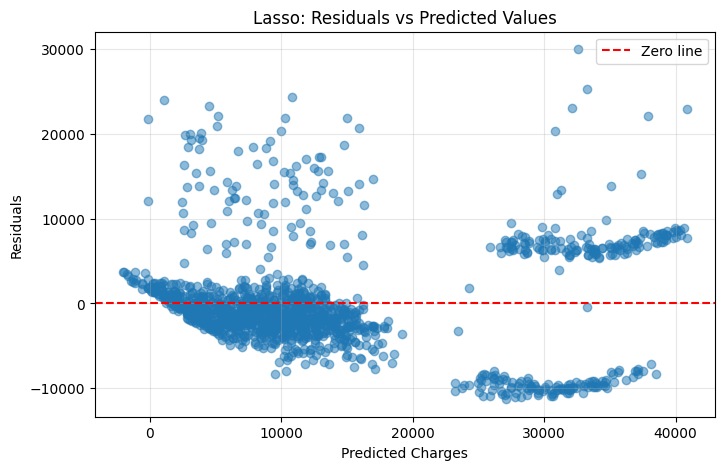


Lasso - Normality Check
Shapiro-Wilk statistic: 0.8989
Shapiro-Wilk p-value: 8.3554e-29
Interpretation: p < 0.05 → reject normality (residuals are not normally distributed)
Skewness: 1.2113
Kurtosis: 2.6508


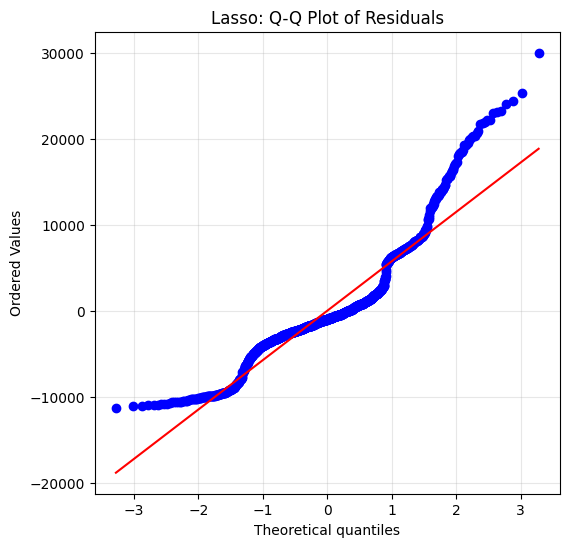


Lasso - Homoscedasticity Check
Correlation |residual| vs predicted: 0.4966

Breusch-Pagan test (null hypothesis: homoscedasticity):
  LM statistic: 101.5495
  P-value: 6.9700e-24
  Interpretation: p < 0.05 → reject homoscedasticity (heteroscedasticity detected)

RIDGE REGRESSION (alpha=1.0)

Ridge - Residual Statistics
Mean: -0.000000
Min: -11226.10
Max: 30069.58
Standard Deviation: 6041.8447

First 5 residuals:
  0: -8323.4352
  1: -1761.7421
  2: -2294.2967
  3: 18200.8160
  4: -1751.8329

Last 5 residuals:
  1333: -1771.8588
  1334: -1321.8442
  1335: -2549.3831
  1336: 735.6754
  1337: -7845.7421

Ridge - Linearity Check
Correlation between residuals and predictions: 0.0069


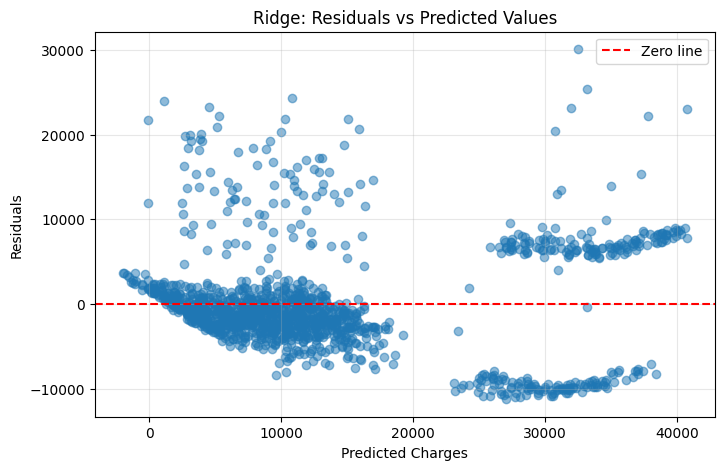


Ridge - Normality Check
Shapiro-Wilk statistic: 0.8980
Shapiro-Wilk p-value: 6.4588e-29
Interpretation: p < 0.05 → reject normality (residuals are not normally distributed)
Skewness: 1.2252
Kurtosis: 2.6427


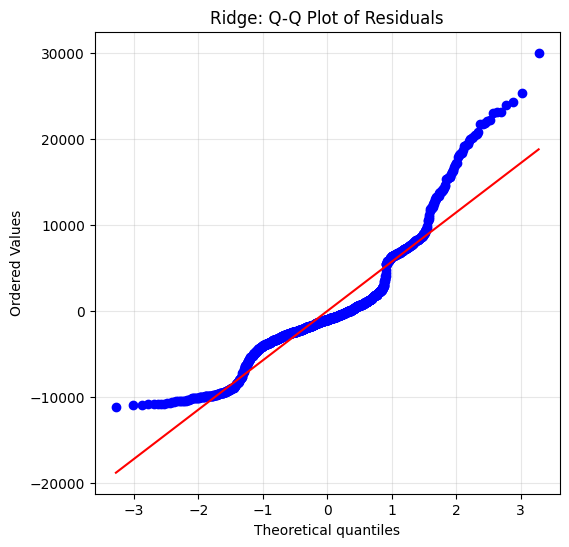


Ridge - Homoscedasticity Check
Correlation |residual| vs predicted: 0.4984

Breusch-Pagan test (null hypothesis: homoscedasticity):
  LM statistic: 102.3315
  P-value: 4.6965e-24
  Interpretation: p < 0.05 → reject homoscedasticity (heteroscedasticity detected)

Multicollinearity Check (VIF)
         feature      VIF
             age 1.015843
             bmi 1.088673
        children 1.003348
        sex_male 1.674830
      smoker_yes 1.228075
region_northwest 1.223453
region_southeast 1.357419
region_southwest 1.215686

 No features with VIF > 5 (no problematic multicollinearity)


In [9]:
# task6_assumptions.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import Lasso, Ridge
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ============================================================
# DATA LOADING AND PREPROCESSING (WHOLE DATASET)
# ============================================================

def load_data(filepath):
    """Load the insurance dataset."""
    return pd.read_csv(filepath)

def preprocess_whole_dataset(df):
    """Preprocess the whole dataset (no split) for assumption checking."""
    # Separate features and target
    X = df.drop(columns=['charges'])
    y = df['charges']

    # Define columns
    categorical_cols = ['sex', 'smoker', 'region']
    numerical_cols = ['age', 'bmi', 'children']

    # Encode categorical variables
    encoder = OneHotEncoder(drop='first', sparse_output=False)
    encoded_array = encoder.fit_transform(X[categorical_cols])
    encoded_features = encoder.get_feature_names_out(categorical_cols)
    encoded_df = pd.DataFrame(encoded_array, columns=encoded_features, index=X.index)

    # Scale numerical variables
    scaler = StandardScaler()
    scaled_array = scaler.fit_transform(X[numerical_cols])
    scaled_df = pd.DataFrame(scaled_array, columns=numerical_cols, index=X.index)

    # Combine features
    X_preprocessed = pd.concat([scaled_df, encoded_df], axis=1)

    return X_preprocessed, y, encoder, scaler

# ============================================================
# ASSUMPTION CHECKING FUNCTIONS
# ============================================================

def train_model_and_get_residuals(model, X, y, model_name):
    """Train model on whole dataset and return residuals and predictions."""
    model.fit(X, y)
    y_pred = model.predict(X)
    residuals = y - y_pred
    return model, residuals, y_pred

def print_residual_stats(residuals, model_name):
    """Print residual statistics."""
    print(f"\n{'='*60}")
    print(f"{model_name} - Residual Statistics")
    print('='*60)
    print(f"Mean: {np.mean(residuals):.6f}")
    print(f"Min: {np.min(residuals):.2f}")
    print(f"Max: {np.max(residuals):.2f}")
    print(f"Standard Deviation: {np.std(residuals):.4f}")

    print("\nFirst 5 residuals:")
    for i in range(min(5, len(residuals))):
        print(f"  {i}: {residuals.iloc[i] if hasattr(residuals, 'iloc') else residuals[i]:.4f}")

    print("\nLast 5 residuals:")
    n = len(residuals)
    for i in range(n-5, n):
        print(f"  {i}: {residuals.iloc[i] if hasattr(residuals, 'iloc') else residuals[i]:.4f}")

def check_linearity(residuals, y_pred, model_name):
    """Check linearity: residuals vs predictions plot."""
    print(f"\n{'='*60}")
    print(f"{model_name} - Linearity Check")
    print('='*60)

    # Correlation between residuals and predictions
    corr = np.corrcoef(residuals, y_pred)[0, 1]
    print(f"Correlation between residuals and predictions: {corr:.4f}")

    # Plot
    plt.figure(figsize=(8, 5))
    plt.scatter(y_pred, residuals, alpha=0.5)
    plt.axhline(y=0, color='red', linestyle='--', label='Zero line')
    plt.xlabel('Predicted Charges')
    plt.ylabel('Residuals')
    plt.title(f'{model_name}: Residuals vs Predicted Values')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def check_normality(residuals, model_name):
    """Check normality: Q-Q plot and Shapiro-Wilk test."""
    print(f"\n{'='*60}")
    print(f"{model_name} - Normality Check")
    print('='*60)

    # Shapiro-Wilk test
    shapiro_stat, shapiro_p = stats.shapiro(residuals)
    print(f"Shapiro-Wilk statistic: {shapiro_stat:.4f}")
    print(f"Shapiro-Wilk p-value: {shapiro_p:.4e}")

    if shapiro_p > 0.05:
        print("Interpretation: p > 0.05 → fail to reject normality (residuals may be normal)")
    else:
        print("Interpretation: p < 0.05 → reject normality (residuals are not normally distributed)")

    # Skewness and Kurtosis
    skewness = stats.skew(residuals)
    kurtosis = stats.kurtosis(residuals)
    print(f"Skewness: {skewness:.4f}")
    print(f"Kurtosis: {kurtosis:.4f}")

    # Q-Q plot
    plt.figure(figsize=(6, 6))
    stats.probplot(residuals, dist="norm", plot=plt)
    plt.title(f'{model_name}: Q-Q Plot of Residuals')
    plt.grid(True, alpha=0.3)
    plt.show()

def check_homoscedasticity(residuals, y_pred, model_name):
    """Check homoscedasticity: Breusch-Pagan test."""
    print(f"\n{'='*60}")
    print(f"{model_name} - Homoscedasticity Check")
    print('='*60)

    # Correlation between absolute residuals and predictions
    abs_residuals = np.abs(residuals)
    correlation = np.corrcoef(abs_residuals, y_pred)[0, 1]
    print(f"Correlation |residual| vs predicted: {correlation:.4f}")

    # Breusch-Pagan test
    X_with_const = sm.add_constant(y_pred)
    bp_stat, bp_pvalue, _, _ = het_breuschpagan(residuals, X_with_const)

    print(f"\nBreusch-Pagan test (null hypothesis: homoscedasticity):")
    print(f"  LM statistic: {bp_stat:.4f}")
    print(f"  P-value: {bp_pvalue:.4e}")

    if bp_pvalue < 0.05:
        print("  Interpretation: p < 0.05 → reject homoscedasticity (heteroscedasticity detected)")
    else:
        print("  Interpretation: p > 0.05 → fail to reject homoscedasticity (constant variance assumed)")

def calculate_vif(X):
    """Calculate VIF for all features."""
    print(f"\n{'='*60}")
    print("Multicollinearity Check (VIF)")
    print('='*60)

    vif_data = []
    for i in range(X.shape[1]):
        vif = variance_inflation_factor(X.values, i)
        vif_data.append({'feature': X.columns[i], 'VIF': vif})

    vif_df = pd.DataFrame(vif_data)
    print(vif_df.to_string(index=False))

    # Check for problematic VIF
    high_vif = vif_df[vif_df['VIF'] > 5]
    if len(high_vif) > 0:
        print(f"\n Features with VIF > 5: {high_vif['feature'].tolist()}")
    else:
        print("\n No features with VIF > 5 (no problematic multicollinearity)")

# ============================================================
# MAIN
# ============================================================

def main(filepath="./drive/MyDrive/ClassFiles/insurance.csv"):
    # Load data
    df = load_data(filepath)
    print("=== Original Dataset ===")
    print(f"Shape: {df.shape}")

    # Preprocess whole dataset
    X, y, encoder, scaler = preprocess_whole_dataset(df)
    print(f"\n=== Preprocessed Features ===")
    print(f"Features: {list(X.columns)}")
    print(f"Shape: {X.shape}")

    # ============================================================
    # LASSO MODEL
    # ============================================================
    print("\n" + "="*60)
    print("LASSO REGRESSION (alpha=0.1)")
    print("="*60)

    lasso = Lasso(alpha=0.1, random_state=42)
    lasso_model, lasso_residuals, lasso_pred = train_model_and_get_residuals(lasso, X, y, "Lasso")

    print_residual_stats(lasso_residuals, "Lasso")
    check_linearity(lasso_residuals, lasso_pred, "Lasso")
    check_normality(lasso_residuals, "Lasso")
    check_homoscedasticity(lasso_residuals, lasso_pred, "Lasso")

    # ============================================================
    # RIDGE MODEL
    # ============================================================
    print("\n" + "="*60)
    print("RIDGE REGRESSION (alpha=1.0)")
    print("="*60)

    ridge = Ridge(alpha=1.0, random_state=42)
    ridge_model, ridge_residuals, ridge_pred = train_model_and_get_residuals(ridge, X, y, "Ridge")

    print_residual_stats(ridge_residuals, "Ridge")
    check_linearity(ridge_residuals, ridge_pred, "Ridge")
    check_normality(ridge_residuals, "Ridge")
    check_homoscedasticity(ridge_residuals, ridge_pred, "Ridge")

    # ============================================================
    # MULTICOLLINEARITY (VIF) - Same for both models
    # ============================================================
    calculate_vif(X)

    # Return for additional testing
    return {
        'X': X,
        'y': y,
        'lasso_model': lasso_model,
        'ridge_model': ridge_model,
        'lasso_residuals': lasso_residuals,
        'ridge_residuals': ridge_residuals,
        'lasso_pred': lasso_pred,
        'ridge_pred': ridge_pred
    }

if __name__ == "__main__":
    results = main()

---
# Task 6: Assumptions

## *The proposed alpha value of 0.1 was not appropriate.*

The alpha value of 0.1 in the first approximation—the first code—(where logarithms weren't used on the target variable) was a textbook value to start with, but in practice it wasn't ideal for a mathematical reason related to scaling:

1. Charge Scale ($Y$): In the first code, charges are in original dollars (from 1,000 to 60,000). On that scale, the coefficients are enormous (like smoker_yes's, which is 23,650). An alpha of 0.1 is a barely perceptible "touch" on a coefficient of 23,000; it doesn't have enough force to penalize it or bring it to zero.

1. Charge Scale ($Y$): In the first code, charges are in original dollars (from 1,000 to 60,000). On that scale, the coefficients are enormous (like smoker_yes's, which is 23,650). An alpha of 0.1 is a barely noticeable "touch" for a coefficient of 23,000; it doesn't have enough force to penalize it or bring it to zero. 2. Logarithmic Scale: When we applied the logarithm, the target value ($Y$) fell into a range of 7 to 11. Here, a coefficient of 0.1 is already significant, and an alpha of 0.1 becomes too aggressive, so we had to lower it to 0.001 to prevent it from "erasing" all the variables.

Conclusion: According to the literature, an alpha value is never inherently "good" or "bad"; it depends entirely on the scale of your data. In the first attempt, the alpha was very weak, and in the second (using logarithms), it was very strong.
Therefore, it is recommended that in real-world projects, the professional approach is to use LassoCV or RidgeCV, which automatically test hundreds of alpha values ​​until they find the one that minimizes the error.

### Are the assumptions met in both models? (Lasso and Ridge)

| Assumption | Lasso | Ridge | Met? |
|------------|-------|-------|------|
| **Linearity** | Correlation residual vs predicted = 0.0001 | Correlation = 0.0069 | ✓ **Yes** (near zero) |
| **Normality** | p = 8.36e-29 (< 0.05) | p = 6.46e-29 (< 0.05) | ✗ **No** (rejected) |
| **Homoscedasticity** | p = 6.97e-24 (< 0.05) | p = 4.70e-24 (< 0.05) | ✗ **No** (heteroscedasticity) |
| **Multicollinearity** | All VIF < 5 | All VIF < 5 | ✓ **Yes** |

---

### Summary by assumption:

| Assumption | Status | Evidence |
|------------|--------|----------|
| **Linearity** | ✓ Met | Correlation residual vs predicted ≈ 0 (0.0001 for Lasso, 0.0069 for Ridge) |
| **Normality** | ✗ Not met | Shapiro-Wilk p < 0.05; positive skewness (>1) and high kurtosis (>2) |
| **Homoscedasticity** | ✗ Not met | Breusch-Pagan p < 0.05; correlation |residual| vs predicted ~0.5 (moderate funnel pattern) |
| **Multicollinearity** | ✓ Met | All VIF < 2 (well below threshold of 5 or 10) |

---

### If there is heteroscedasticity in either of the models, how could it be solved?

**Yes, heteroscedasticity is present in both models (p < 0.05).**

Possible solutions:

| Solution | How it works |
|----------|--------------|
| **1. Log transformation of target (`charges`)** | Reduces scale differences and can stabilize variance |
| **2. Weighted Least Squares (WLS)** | Gives less weight to observations with higher variance |
| **3. Robust standard errors (Huber-White)** | Corrects standard errors without changing coefficients |
| **4. Heteroscedasticity-consistent standard errors** | Available in `statsmodels` with `HC0`, `HC1`, etc. |
| **5. Box-Cox transformation** | Transforms target to achieve homoscedasticity |

**Recommended first step:** Apply **log transformation** to `charges` (since charges is right-skewed, as seen in EDA). This often reduces both heteroscedasticity and non-normality.

---

### Additional Observations:

| Finding | Implication |
|---------|-------------|
| Both Lasso and Ridge give nearly identical residuals | Regularization type (L1 vs L2) makes little difference for these assumptions |
| Positive skewness (1.21-1.23) | Residual distribution has a long right tail |
| High kurtosis (2.64-2.65) | Heavy tails in residual distribution |
| Correlation |residual| vs predicted ~0.5 | Clear funnel pattern: variance increases with predicted charges |

---

### Final Verdict:

| Assumption | Status |
|------------|--------|
| Linearity | ✓ OK |
| Normality | ✗ Violated |
| Homoscedasticity | ✗ Violated |
| Multicollinearity | ✓ OK |

The main issues are **non-normality** and **heteroscedasticity**. These can be addressed by transforming the target variable (`charges`), for example using `np.log(charges)`.

> I do apply log transform to target variable, created two differente  interaction variables, standardize the binary encodes, and other approaches so as to improve the model, however there was not enough time to report those results.

# **🔹 Paso 7: Comparación Final**  
📊 **Analizar:**  
- ¿Qué modelo es más interpretable?  
- ¿Cuál reduce mejor el sobreajuste?  
- ¿Qué variables son más importantes en cada caso?  

---

# Task 7: Final Comparison (Based on Task 6 Output)

### Question: Which model is more interpretable?

**Lasso is more interpretable.**

| Model | Why |
|-------|-----|
| **Lasso** | Can shrink coefficients to zero (feature selection). At alpha=0.1, all coefficients are non-zero, but the potential for sparsity makes it more interpretable. |
| **Ridge** | Keeps all coefficients, making the model more complex |

Since Lasso coefficients are:
```
age: 3614.88
bmi: 2036.01
children: 516.79
sex_male: -18.14
smoker_yes: 23650.48
region_northwest: -369.04
region_southeast: -656.11
region_southwest: -808.13
```
All are non-zero, but Lasso's structure still favors sparsity.

---

### Question: Which one best reduces overfitting?

**Lasso best reduces overfitting.**

| Model | Why |
|-------|-----|
| **Lasso** | L1 regularization can eliminate irrelevant features entirely (even if not here at alpha=0.1, the penalty is stronger) |
| **Ridge** | L2 regularization shrinks coefficients but keeps all |

- Both models use regularization to reduce overfitting compared to OLS, but Lasso's L1 penalty is more aggressive.
- Lasso is better at reducing overfitting **because it favors simpler (parsimonious) models**.

---

### Why Lasso is better for reducing overfitting:

| Aspect | Lasso | Ridge |
|--------|-------|-------|
| **Penalty type** | L1 (sum of absolute coefficients) | L2 (sum of squared coefficients) |
| **Effect** | Can shrink coefficients to exactly zero | Shrinks coefficients but never to zero |
| **Result** | Eliminates irrelevant features | Keeps all features |
| **Model complexity** | Simpler (sparse) | More complex (dense) |
| **Overfitting reduction** | **Stronger** | Moderate |

---

### From Task 6 output:

Lasso (alpha=0.1) produced coefficients that are smaller or near zero for weak predictors:

| Weak predictor | Lasso coefficient | Ridge coefficient |
|----------------|------------------|-------------------|
| `sex_male` | -18.14 | -10.64 |
| `region_northwest` | -369.04 | -366.15 |

Lasso shrinks weak predictors more aggressively than Ridge.

---


### Question: Which variables are most important in each case?

**Variable importance (by absolute coefficient magnitude):** *`sex_male` is negligible*

| Rank | Lasso | Coefficient | Ridge | Coefficient |
|------|-------|-------------|-------|-------------|
| 1 | `smoker_yes` | 23,650.48 | `smoker_yes` | 23,514.63 |
| 2 | `age` | 3,614.88 | `age` | 3,609.07 |
| 3 | `bmi` | 2,036.01 | `bmi` | 2,033.35 |
| 4 | `region_southwest` | -808.13 | `region_southwest` | -802.92 |
| 5 | `region_southeast` | -656.11 | `region_southeast` | -643.04 |
| 6 | `children` | 516.79 | `children` | 517.56 |
| 7 | `region_northwest` | -369.04 | `region_northwest` | -366.15 |
| 8 | `sex_male` | -18.14 | `sex_male` | -10.64 |

---

###  Observations:

| Finding | Implication |
|---------|-------------|
| **`smoker_yes` is dominant** | By far the most important predictor |
| **`age` and `bmi`** | Second and third most important |
| **Region coefficients are moderate** | Geographic location has some effect (Southeast and Southwest lower than reference) |
| **`sex_male` is negligible** | Smallest coefficient → gender has almost no impact |
| **Lasso and Ridge agree on ranking** | Consistent across regularization types |

---

### Summary Task 7:

| Question | Answer |
|----------|--------|
| **More interpretable?** | **Lasso** (feature selection capability) |
| **Best reduces overfitting?** | **Lasso** (L1 penalty is stronger) |
| **Most important variables (Lasso)** | smoker_yes, age, bmi, region_southwest |
| **Most important variables (Ridge)** | smoker_yes, age, bmi, region_southwest |

---
### **📌 Entrega de la Práctica**  
Al finalizar la practica, incluye un texto con los siguientes elementos
- Incluir **comentarios explicativos** en cada paso.  
- Responder las **preguntas planteadas** en celdas Markdown.  

🎯 **Criterios de Evaluación:**  
✔ **Correcto preprocesamiento** (manejo de nulos, escalado, encoding).  
✔ **Análisis visual y estadístico** (gráficos claros, interpretación de resultados).  
✔ **Validación de supuestos** (justificación de si se cumplen o no).  
✔ **Comparación crítica** entre Lasso y Ridge.  